In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/agneaybnair/country/country_wise_latest.csv")

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.columns

In [ ]:
df.isnull().sum()

In [ ]:
df.nunique()

In [ ]:
sns.scatterplot(x=df["Country/Region"],y=df["Confirmed last week"])

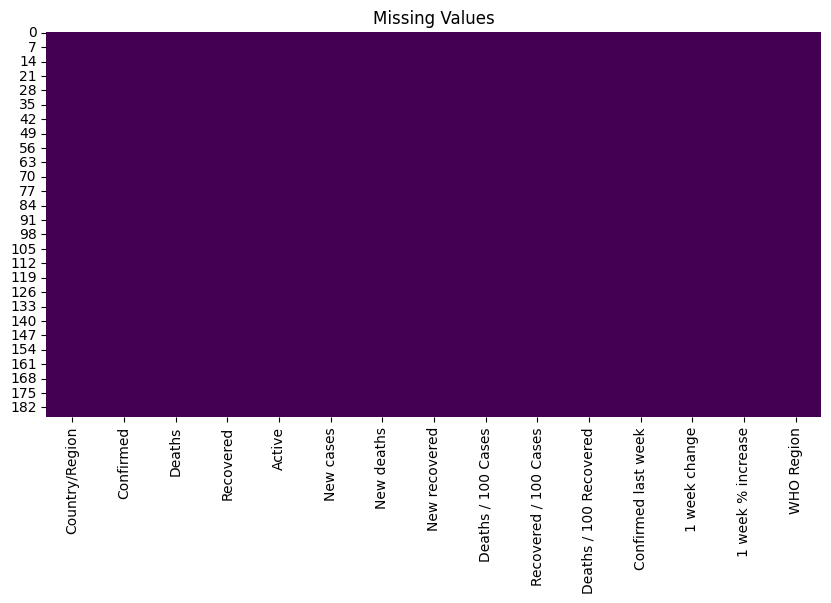

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

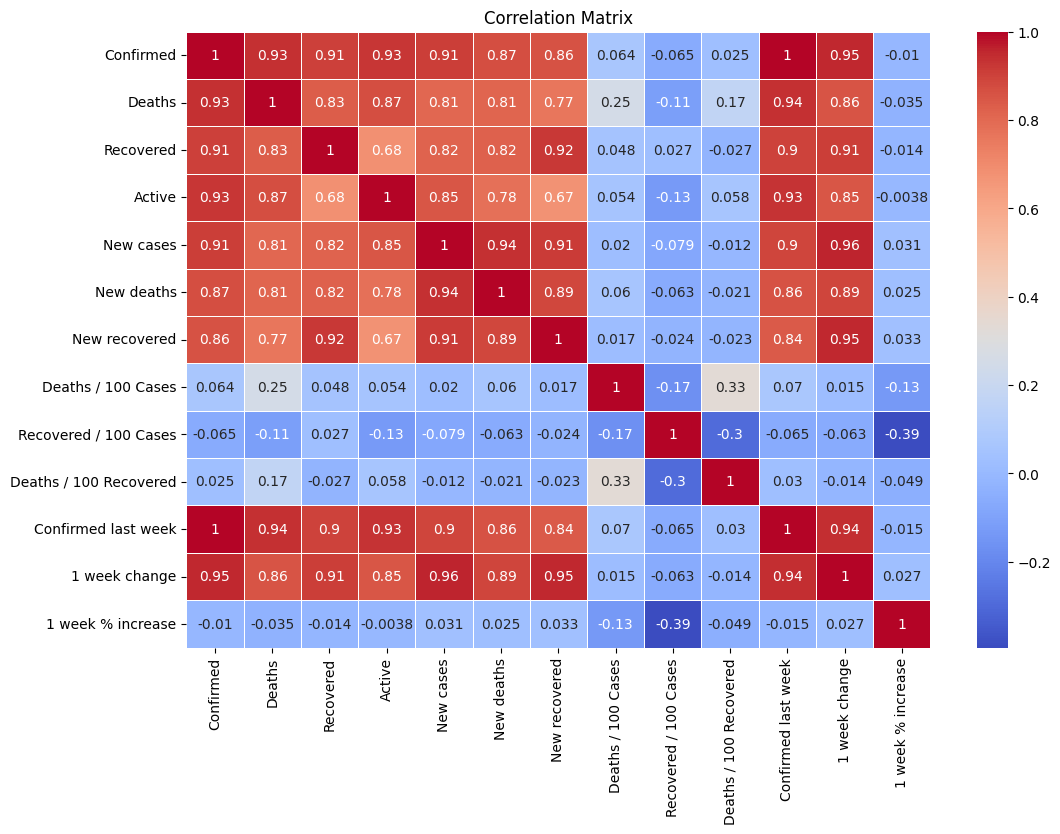

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

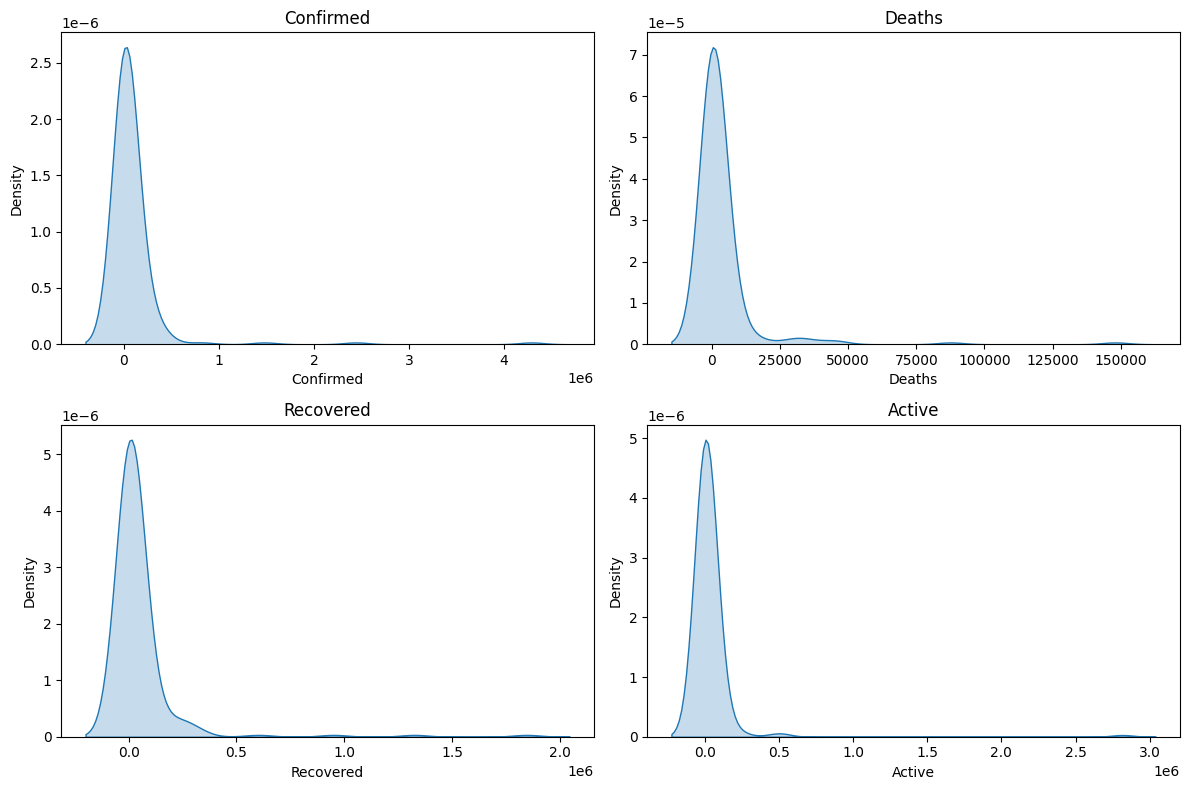

In [ ]:
columns = ["Confirmed","Deaths","Recovered","Active"]

fig, axes = plt.subplots(2,2,figsize=(12,8))

for ax,col in zip(axes.flatten(),columns):
    sns.kdeplot(df[col], fill=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()


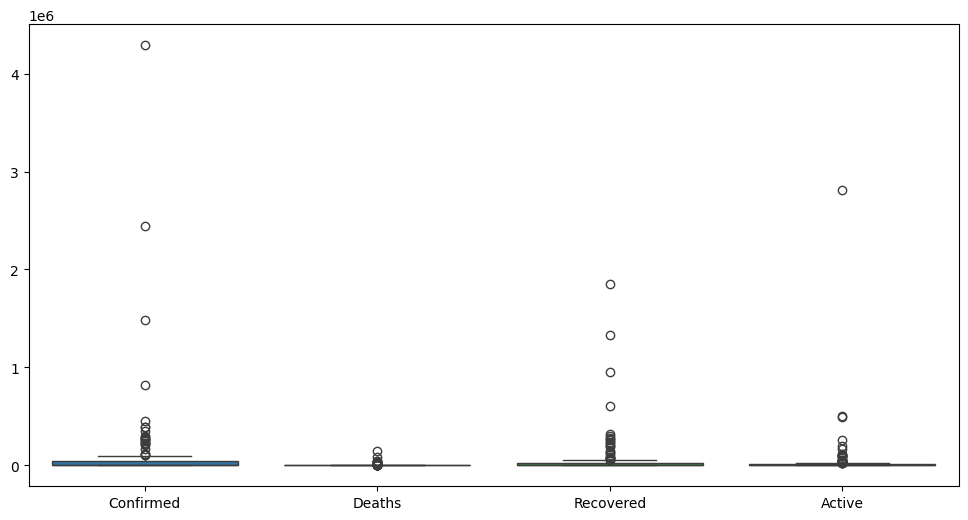

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[
        ["Confirmed","Deaths","Recovered","Active"]
    ]
)

plt.show()

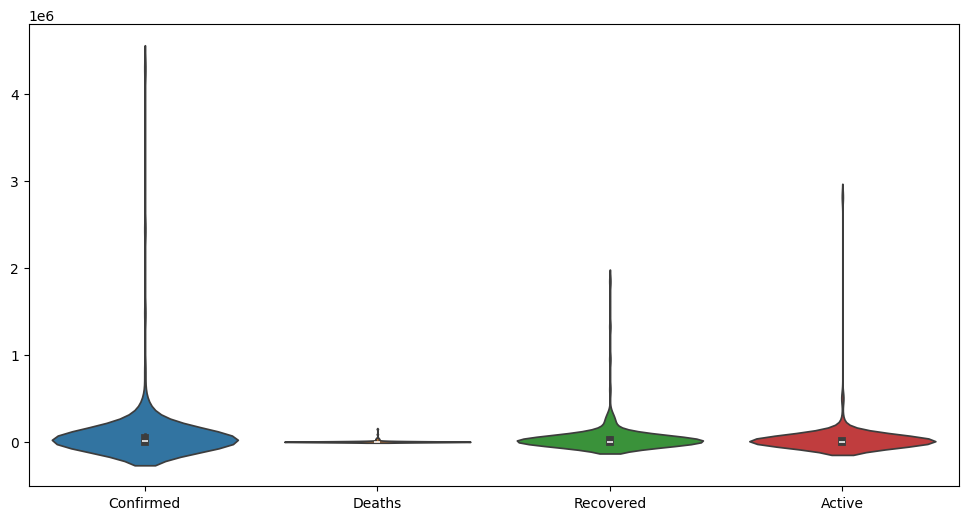

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df[
        ["Confirmed","Deaths","Recovered","Active"]
    ]
)

plt.show()

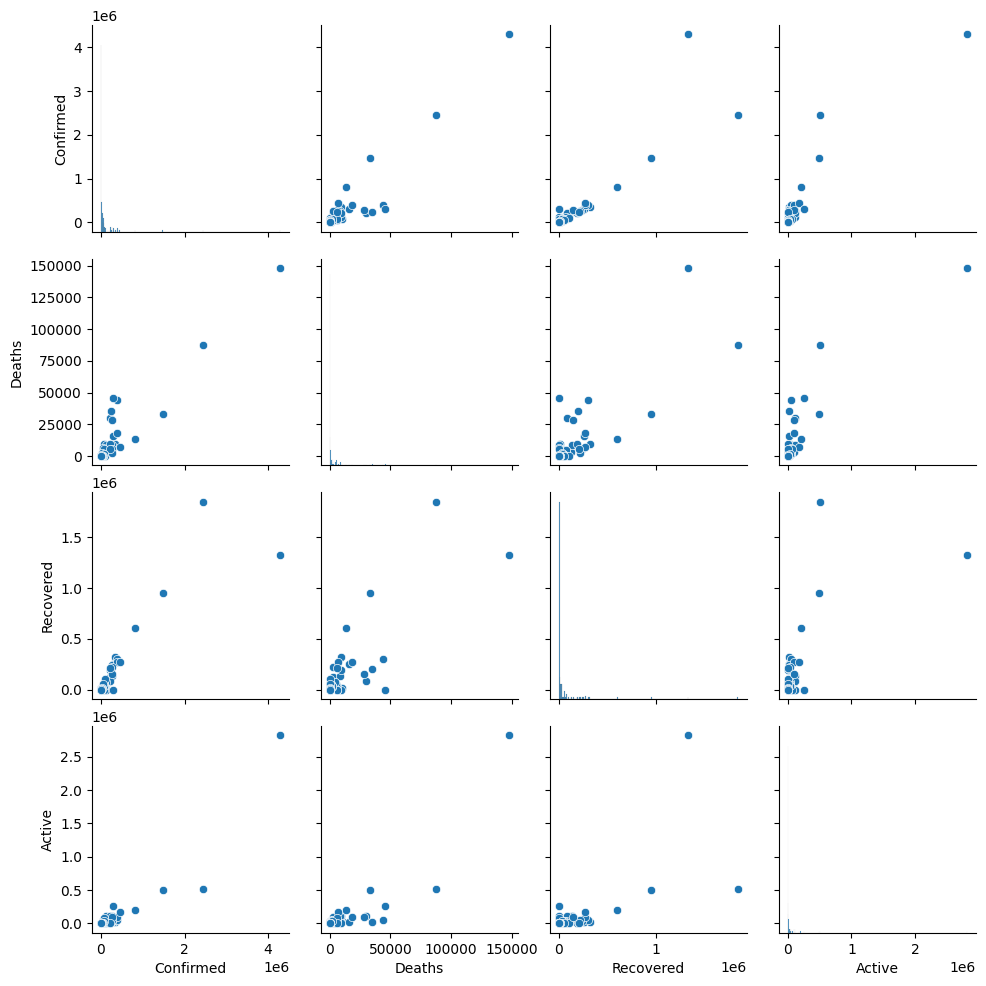

In [ ]:
sns.pairplot(
    df[
        [
            "Confirmed",
            "Deaths",
            "Recovered",
            "Active"
        ]
    ]
)

plt.show()

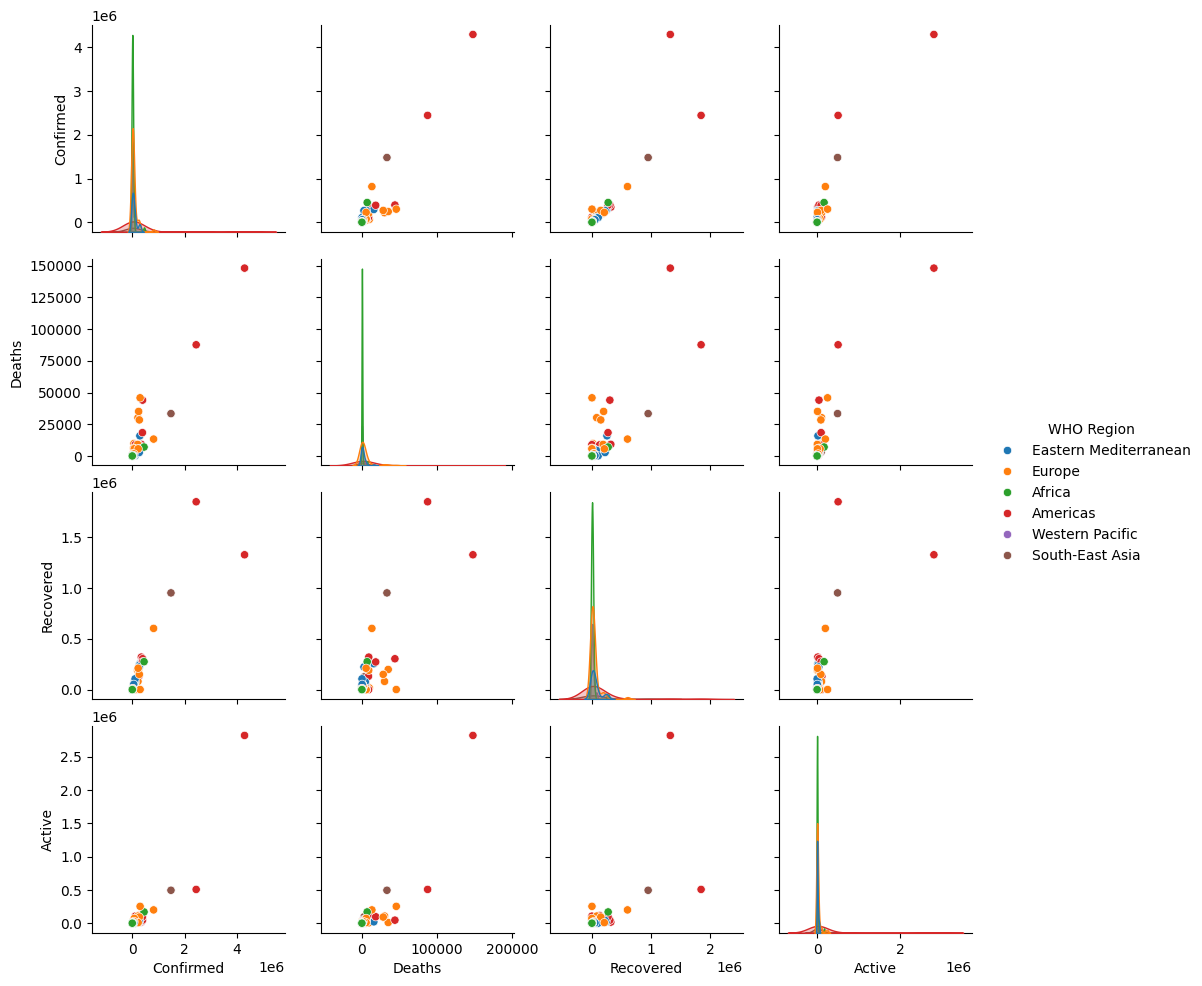

In [ ]:
sns.pairplot(
    df,
    vars=[
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active"
    ],
    hue="WHO Region"
)

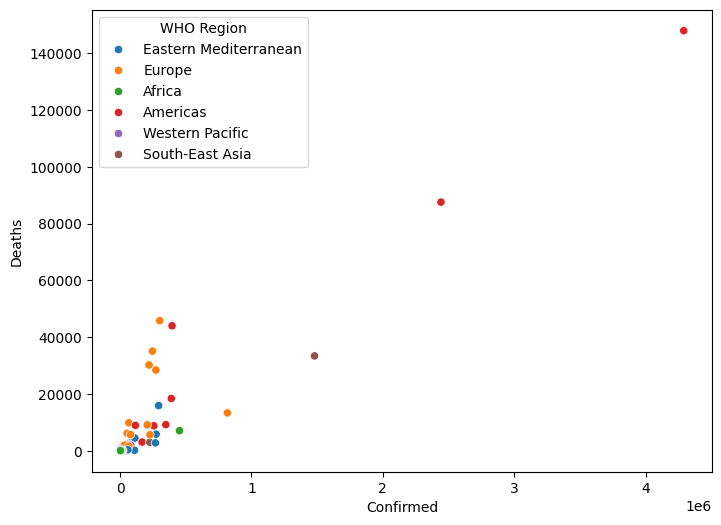

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Confirmed",
    y="Deaths",
    hue="WHO Region"
)

plt.show()

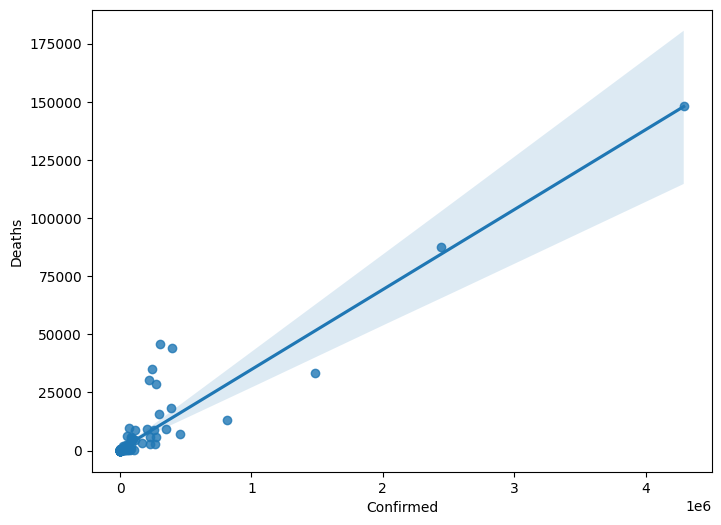

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Confirmed",
    y="Deaths"
)

plt.show()

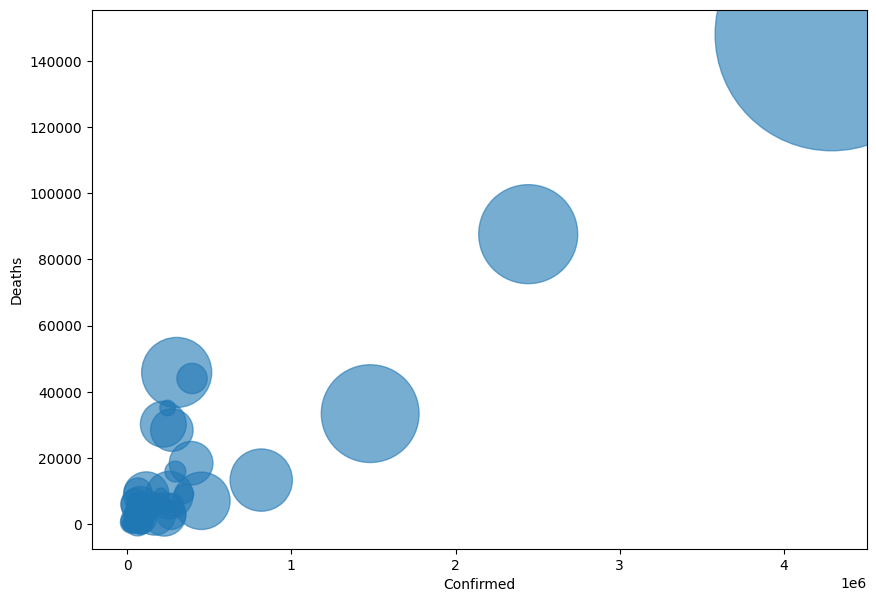

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["Confirmed"],
    df["Deaths"],
    s=df["Active"]/100,
    alpha=0.6
)

plt.xlabel("Confirmed")
plt.ylabel("Deaths")
plt.show()

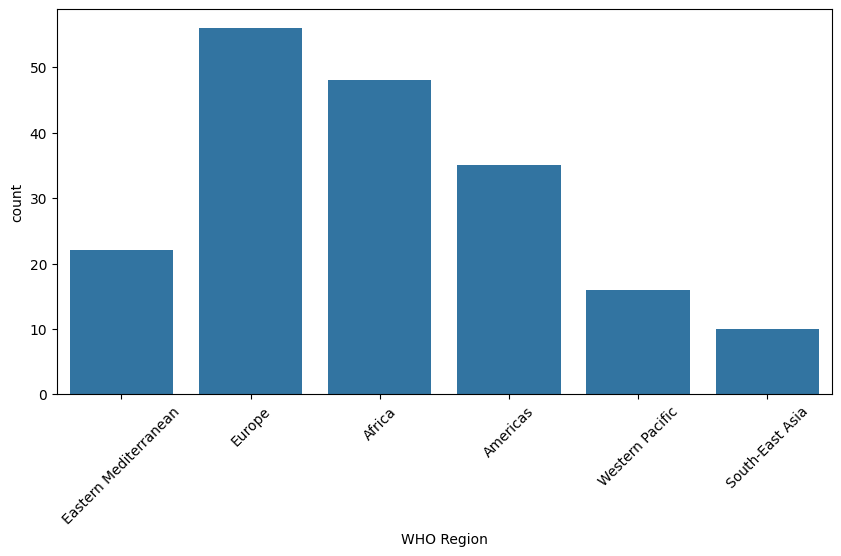

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="WHO Region"
)

plt.xticks(rotation=45)
plt.show()

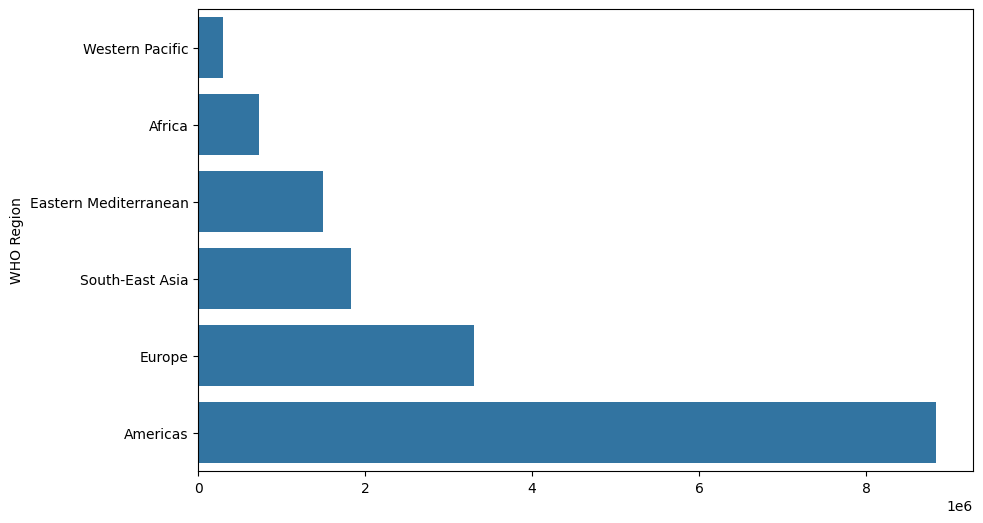

In [ ]:
region = df.groupby("WHO Region")["Confirmed"].sum().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=region.values,
    y=region.index
)

plt.show()

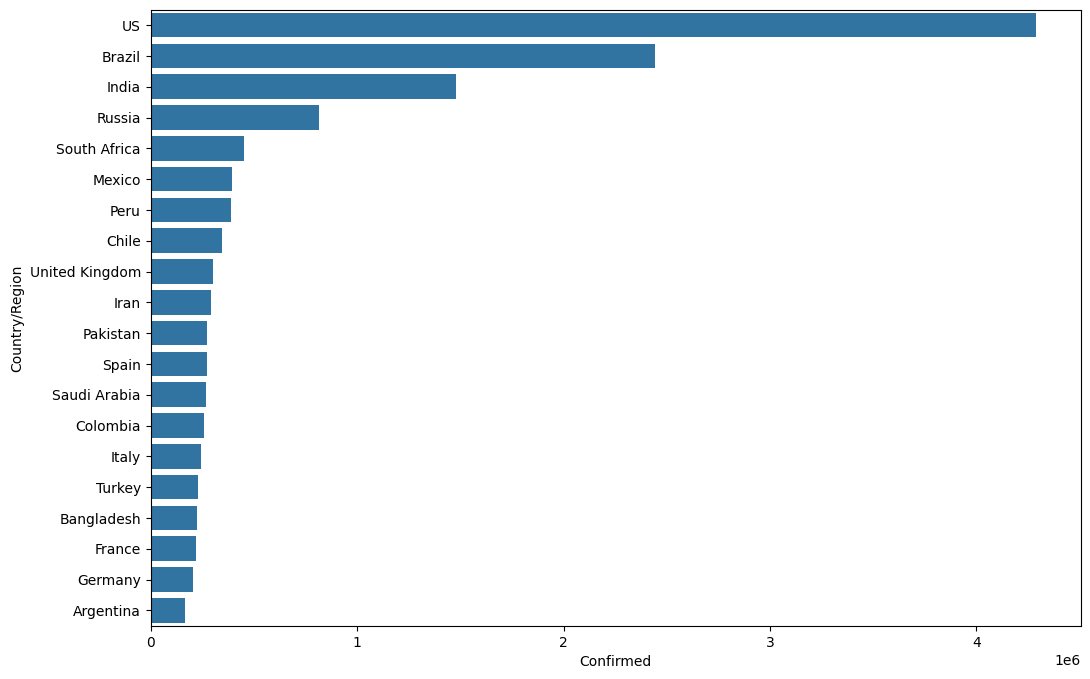

In [ ]:
top = df.nlargest(20,"Confirmed")

plt.figure(figsize=(12,8))

sns.barplot(
    data=top,
    x="Confirmed",
    y="Country/Region"
)

plt.show()

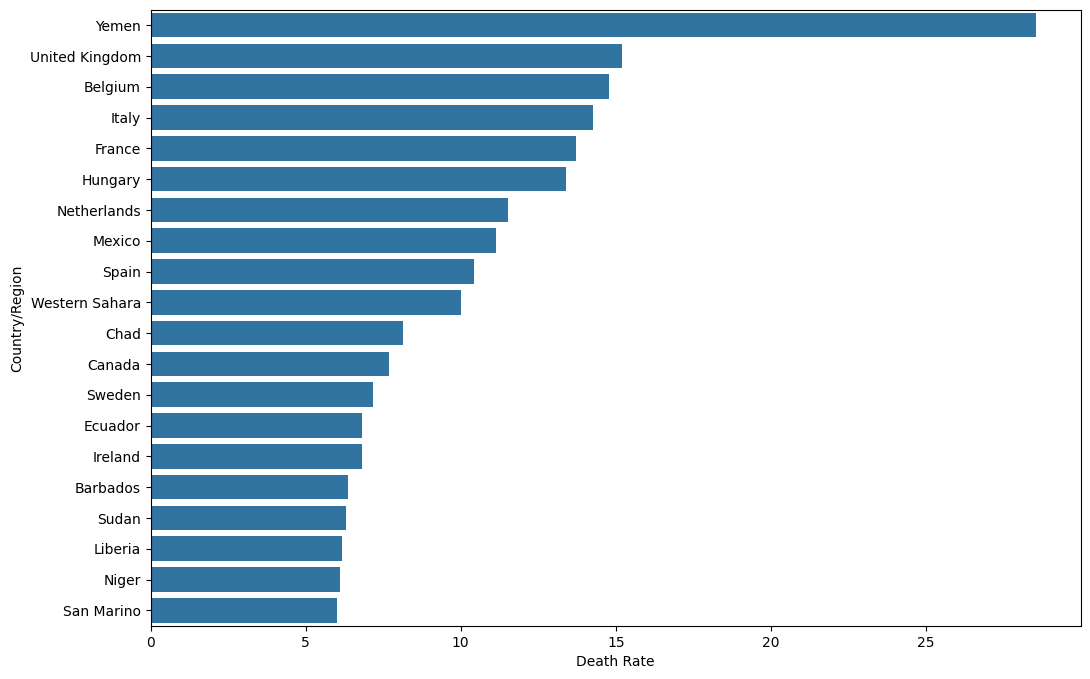

In [ ]:
df["Death Rate"] = (
    df["Deaths"]/df["Confirmed"]
)*100

top = df.nlargest(20,"Death Rate")

plt.figure(figsize=(12,8))

sns.barplot(
    data=top,
    x="Death Rate",
    y="Country/Region"
)

plt.show()

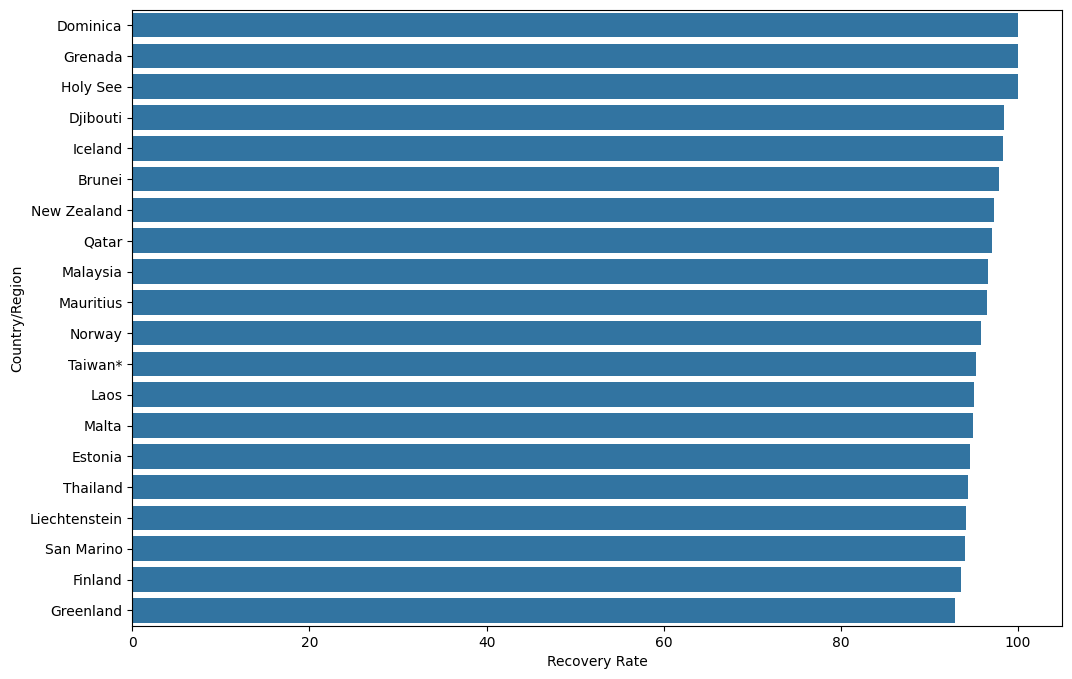

In [ ]:
df["Recovery Rate"] = (
    df["Recovered"]/df["Confirmed"]
)*100

plt.figure(figsize=(12,8))

sns.barplot(
    data=df.nlargest(20,"Recovery Rate"),
    x="Recovery Rate",
    y="Country/Region"
)

plt.show()

<Axes: xlabel='Active Rate', ylabel='Count'>

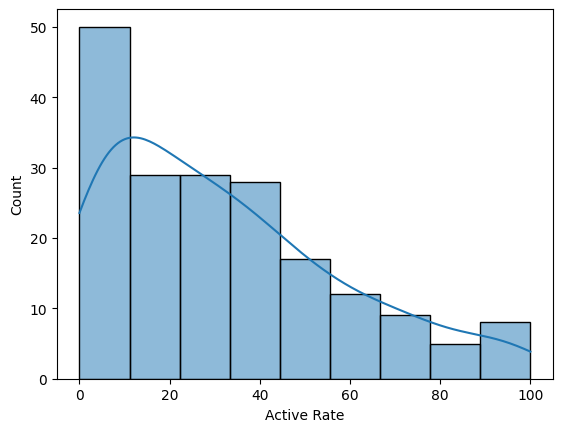

In [ ]:
df["Active Rate"] = (
    df["Active"]/df["Confirmed"]
)*100

sns.histplot(df["Active Rate"], kde=True)

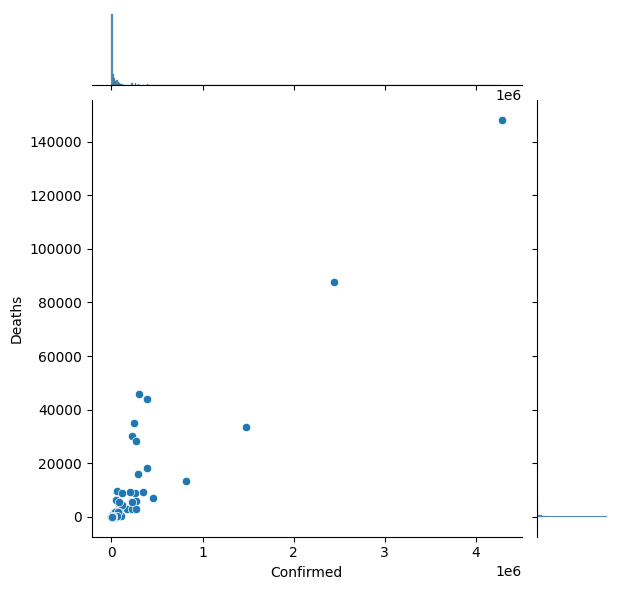

In [ ]:
sns.jointplot(
    data=df,
    x="Confirmed",
    y="Deaths",
    kind="scatter"
)

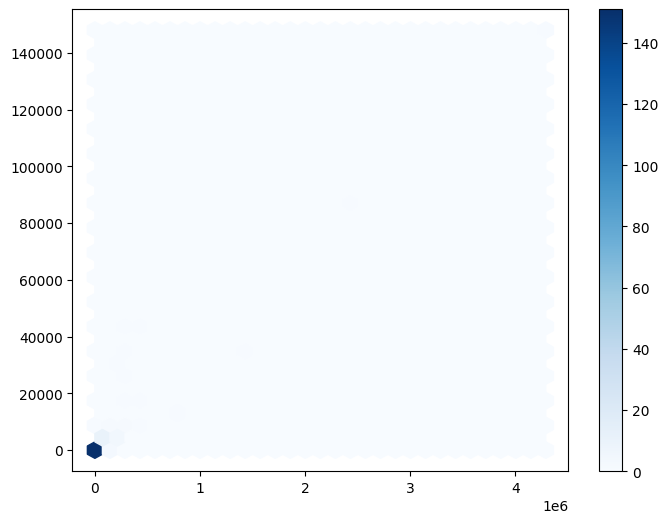

In [ ]:
plt.figure(figsize=(8,6))

plt.hexbin(
    df["Confirmed"],
    df["Deaths"],
    gridsize=30,
    cmap="Blues"
)

plt.colorbar()
plt.show()

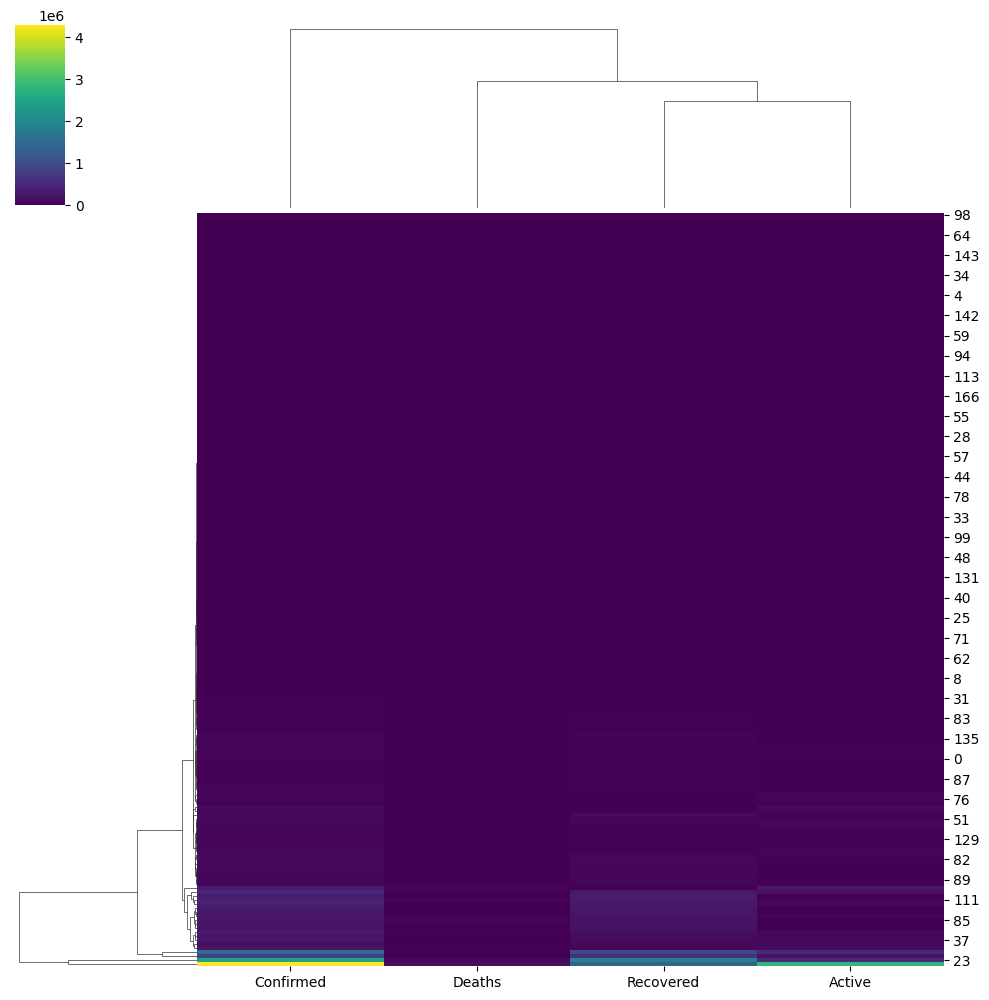

In [ ]:
sns.clustermap(
    df[
        [
            "Confirmed",
            "Deaths",
            "Recovered",
            "Active"
        ]
    ],
    figsize=(10,10),
    cmap="viridis"
)

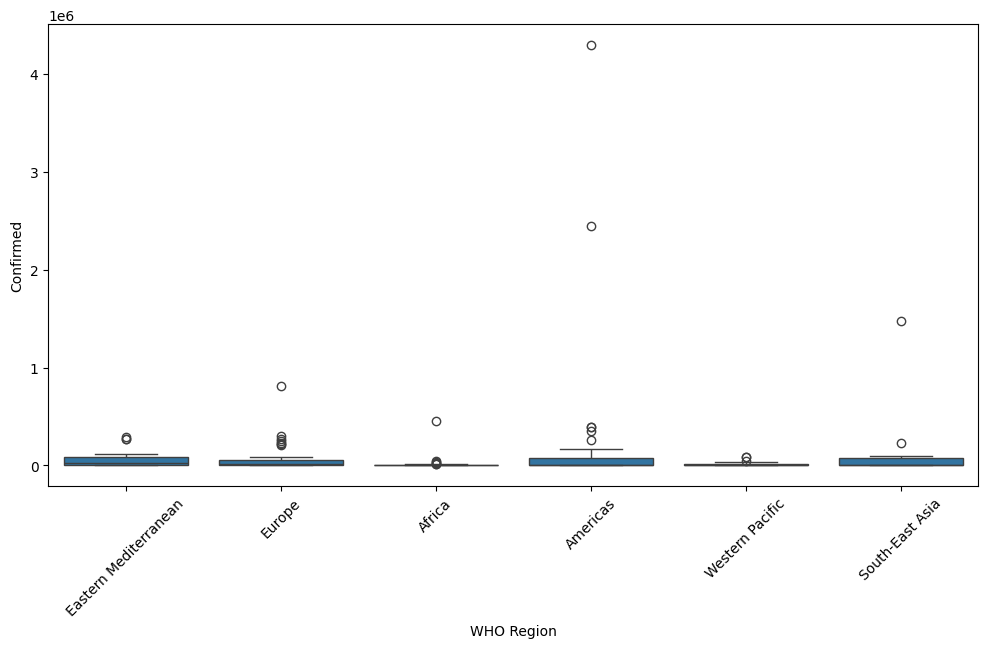

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="WHO Region",
    y="Confirmed"
)

plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Eastern Mediterranean'),
  Text(1, 0, 'Europe'),
  Text(2, 0, 'Africa'),
  Text(3, 0, 'Americas'),
  Text(4, 0, 'Western Pacific'),
  Text(5, 0, 'South-East Asia')])

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 37.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


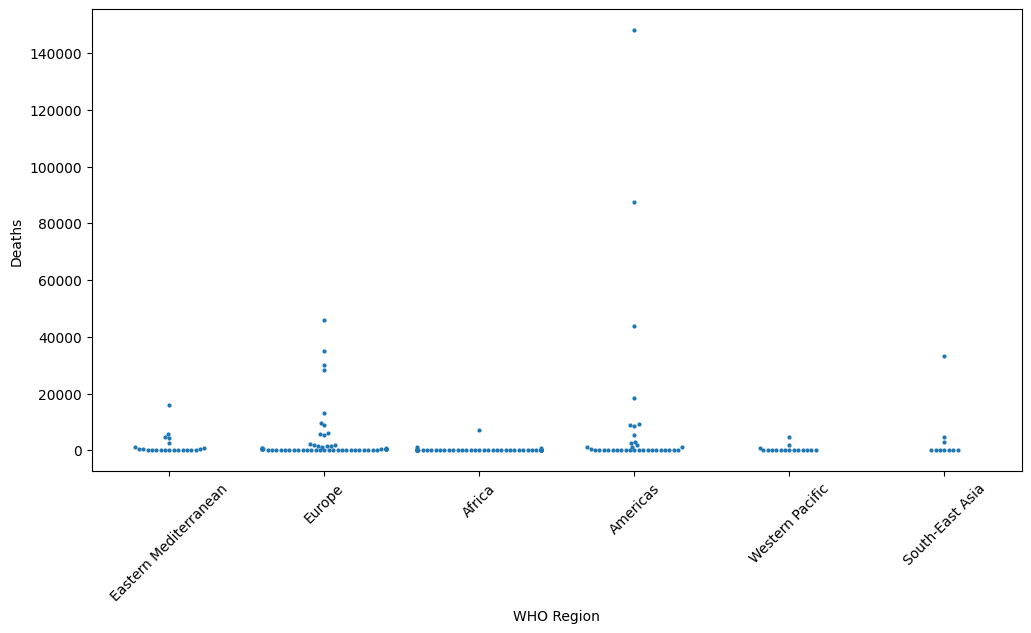

In [ ]:
plt.figure(figsize=(12,6))

sns.swarmplot(
    data=df,
    x="WHO Region",
    y="Deaths",
    size=3
)

plt.xticks(rotation=45)

<Axes: xlabel='WHO Region', ylabel='Recovered'>

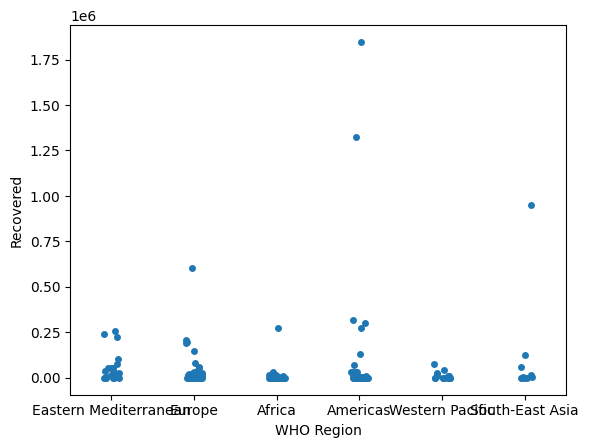

In [ ]:
sns.stripplot(
    data=df,
    x="WHO Region",
    y="Recovered",
    jitter=True
)

<Axes: xlabel='Confirmed', ylabel='Proportion'>

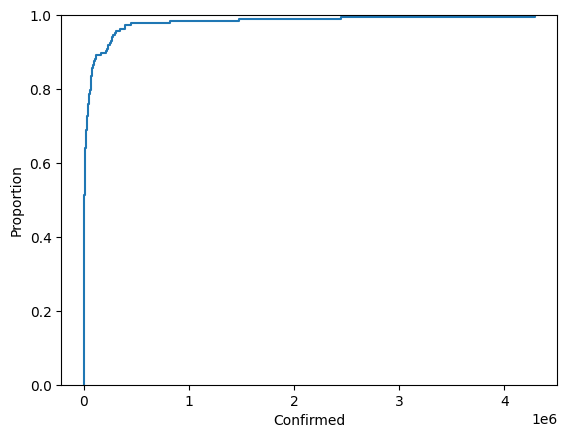

In [ ]:
sns.ecdfplot(df["Confirmed"])

<Axes: xlabel='1 week % increase', ylabel='Count'>

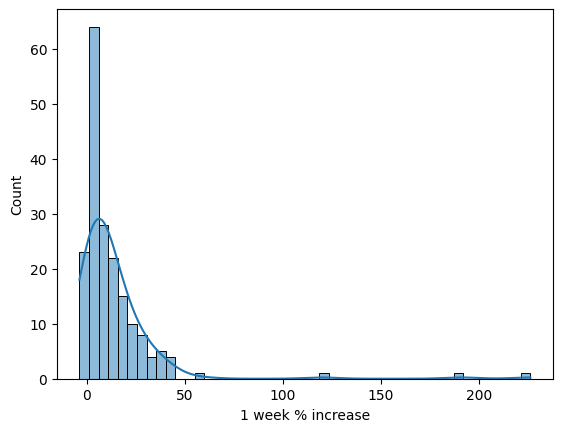

In [ ]:
sns.histplot(
    df["1 week % increase"],
    kde=True
)

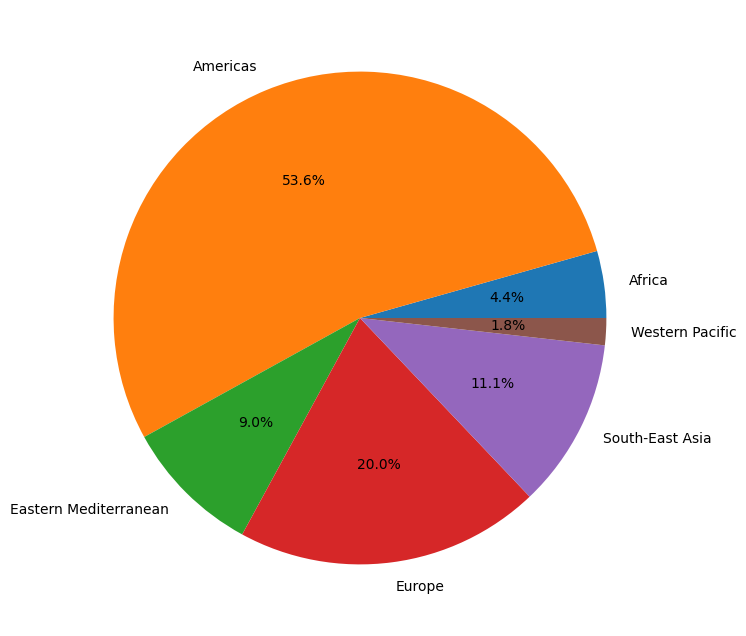

In [ ]:
region = df.groupby("WHO Region")["Confirmed"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    region,
    labels=region.index,
    autopct="%1.1f%%"
)

plt.show()

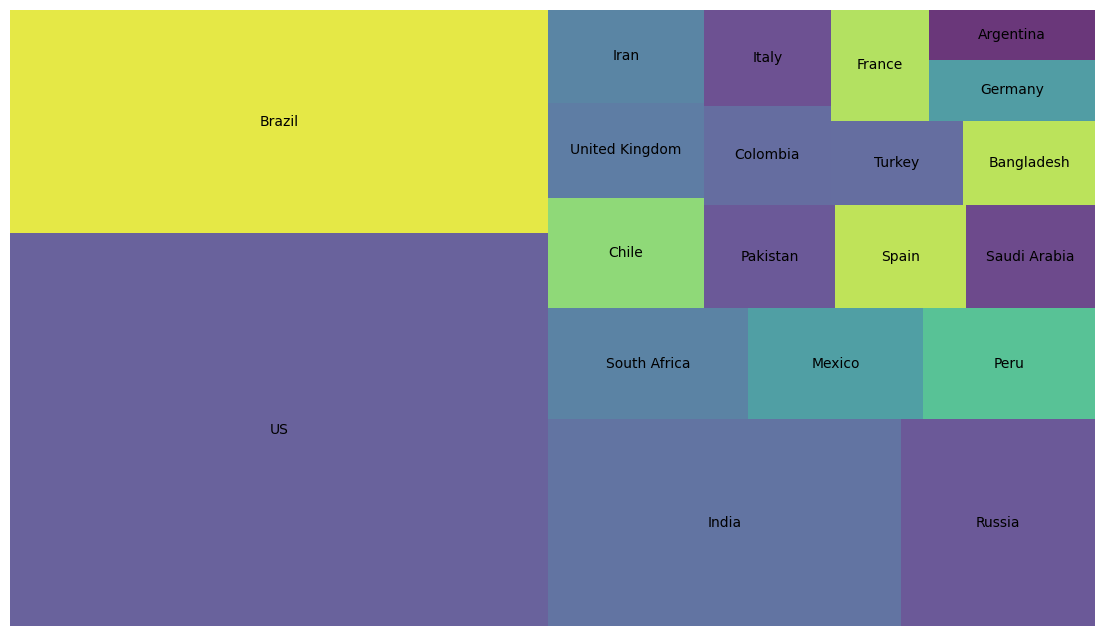

In [ ]:
import squarify

top = df.nlargest(20,"Confirmed")

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=top["Confirmed"],
    label=top["Country/Region"],
    alpha=0.8
)

plt.axis("off")
plt.show()

<Axes: >

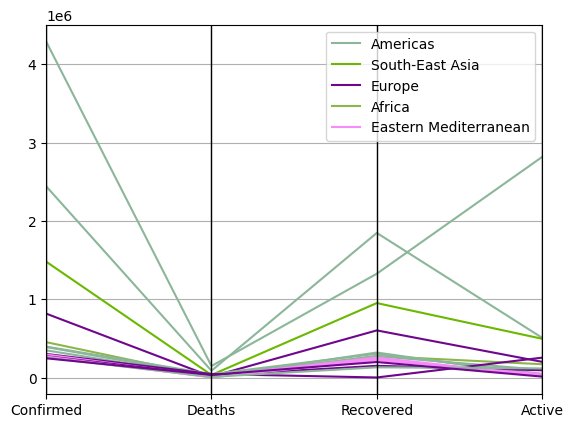

In [ ]:
from pandas.plotting import parallel_coordinates

sample = df.nlargest(15,"Confirmed")

parallel_coordinates(
    sample[
        [
            "WHO Region",
            "Confirmed",
            "Deaths",
            "Recovered",
            "Active"
        ]
    ],
    "WHO Region"
)

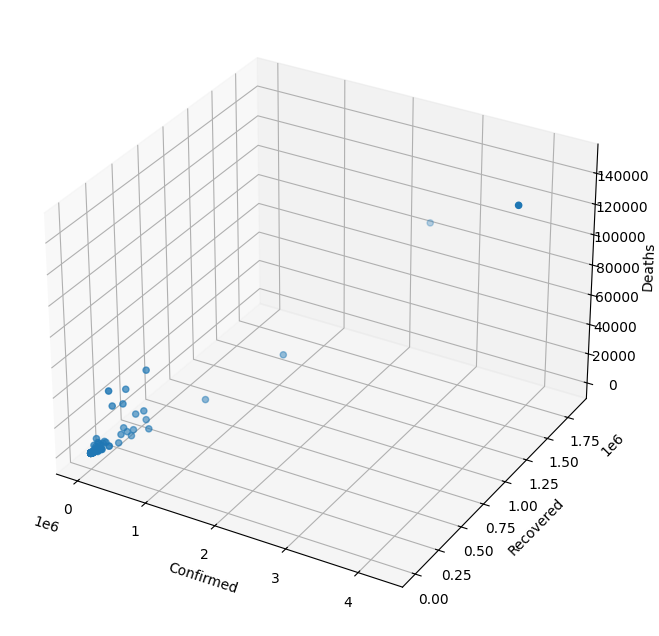

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Confirmed"],
    df["Recovered"],
    df["Deaths"]
)

ax.set_xlabel("Confirmed")
ax.set_ylabel("Recovered")
ax.set_zlabel("Deaths")

plt.show()

## Data Inferences

Based on the exploratory data analysis, here are some key inferences:

1.  **Missing Values:** The heatmap of missing values showed no significant missing data across the columns, indicating a relatively clean dataset.
2.  **Correlation:** The correlation matrix revealed strong positive correlations between 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases, which is expected as these metrics are directly related to the disease progression.
3.  **Distribution of Cases:** Kernel Density Estimate (KDE) plots and box plots for 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases showed skewed distributions, with a few countries having significantly higher numbers, suggesting a heavy-tailed distribution often seen in infectious disease data.
4.  **Pairwise Relationships:** Pair plots and scatter plots highlighted strong positive relationships between 'Confirmed' cases and 'Deaths', as well as 'Confirmed' and 'Recovered' cases. The `hue='WHO Region'` in pair plots indicated that different WHO regions have varying distributions of these metrics.
5.  **Geographical Impact:**
    *   The bar plot of 'Confirmed' cases by 'WHO Region' showed that the 'Americas' region had the highest number of confirmed cases, followed by 'Europe'.
    *   Similarly, the count plot for 'WHO Region' indicated a higher representation of countries from specific regions.
6.  **Death Rate and Recovery Rate:**
    *   The 'Death Rate' was calculated as (Deaths / Confirmed) * 100. Countries with the highest death rates were identified, which could be due to various factors like healthcare capacity, age demographics, or reporting standards.
    *   The 'Recovery Rate' was calculated as (Recovered / Confirmed) * 100, showing countries with high recovery percentages.
7.  **Active Rate Distribution:** The histogram with KDE for 'Active Rate' provided insight into the distribution of the percentage of active cases relative to confirmed cases across countries.
8.  **Outliers and Variations:** Box plots and violin plots, especially for 'Confirmed' and 'Deaths' by 'WHO Region', revealed significant variations and potential outliers within and across regions, indicating disparities in the impact of the pandemic.
9.  **Confirmed vs. Deaths (3D):** The 3D scatter plot of 'Confirmed', 'Recovered', and 'Deaths' visually represented the interdependencies of these three critical indicators.
10. **Treemap:** The treemap of top 20 countries by 'Confirmed' cases visually emphasized the countries most affected in terms of total confirmed cases.